In [2]:
import os, json
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username": "ishwarirautray",
    "key": "KGAT_c42443df0152824059832271ff3ac0e1"
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
plantvillage-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset ready!


In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform pipeline created!")
print("Steps:", len(transform.transforms))

Transform pipeline created!
Steps: 3


In [5]:
base_path = "plantvillage/plantvillage dataset/color"

dataset = datasets.ImageFolder(base_path, transform=transform)

print(f"Total images: {len(dataset)}")
print(f"Total classes: {len(dataset.classes)}")
print(f"\nFirst 5 classes: {dataset.classes[:5]}")
print(f"\nClass to index mapping (first 5):")
for cls, idx in list(dataset.class_to_idx.items())[:5]:
    print(f"  {cls} → {idx}")

Total images: 54305
Total classes: 38

First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Class to index mapping (first 5):
  Apple___Apple_scab → 0
  Apple___Black_rot → 1
  Apple___Cedar_apple_rust → 2
  Apple___healthy → 3
  Blueberry___healthy → 4


In [6]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Training images: {train_size}")
print(f"Validation images: {val_size}")
print(f"Split ratio: 80% train, 20% validation")

Training images: 43444
Validation images: 10861
Split ratio: 80% train, 20% validation


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"\n32 images per batch")
print(f"Each batch shape will be: [32, 3, 224, 224]")

Training batches: 1358
Validation batches: 340

32 images per batch
Each batch shape will be: [32, 3, 224, 224]


In [8]:
images, labels = next(iter(train_loader))

print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")
print(f"Label values in this batch: {labels[:8]}")
print(f"Disease names for first 8:")
for i in range(8):
    print(f"  {labels[i].item()} → {dataset.classes[labels[i]]}")

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Label values in this batch: tensor([22, 16, 24,  4, 30, 35, 15, 35])
Disease names for first 8:
  22 → Potato___healthy
  16 → Peach___Bacterial_spot
  24 → Soybean___healthy
  4 → Blueberry___healthy
  30 → Tomato___Late_blight
  35 → Tomato___Tomato_Yellow_Leaf_Curl_Virus
  15 → Orange___Haunglongbing_(Citrus_greening)
  35 → Tomato___Tomato_Yellow_Leaf_Curl_Virus


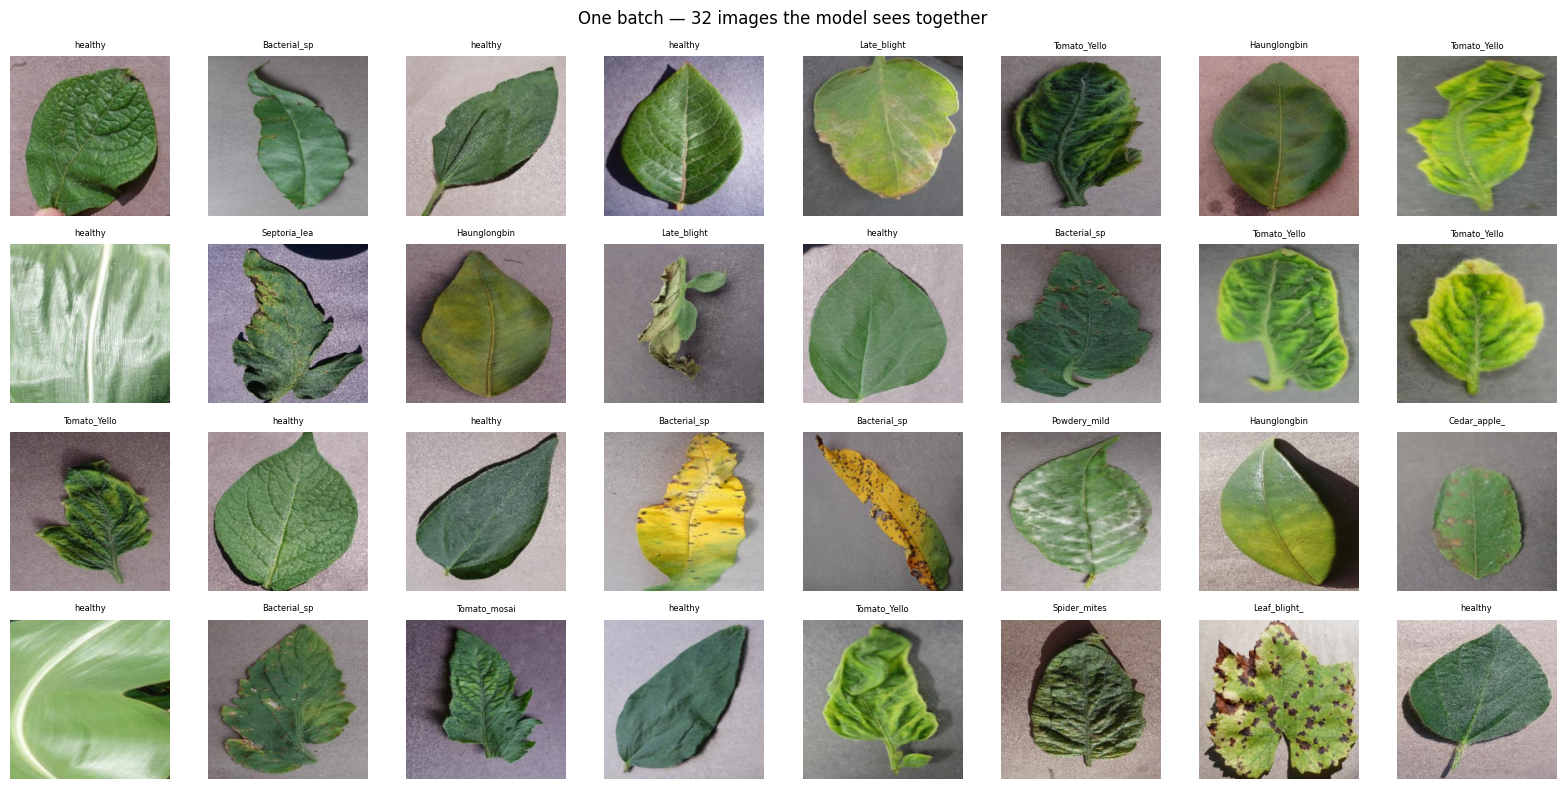

In [9]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(32):
    img = images[i].numpy().transpose(1, 2, 0)

    # Undo normalization so image looks normal
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[labels[i]]
                      .split("___")[1][:12], fontsize=6)
    axes[i].axis("off")

plt.suptitle("One batch — 32 images the model sees together", fontsize=12)
plt.tight_layout()
plt.show()